In [5]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict


In [3]:
#we will create a typed dictor here
class BMIstate(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    
    

In [12]:
def Calculate_bmi(state: BMIstate) -> BMIstate:
    weight = state['weight_kg']
    height = state['height_m']
    
    bmi = weight / height ** 2
    
    state['bmi'] = round(bmi , 2)
    return state



In [13]:
#now create the object of this class and input will be the class name
graph = StateGraph(BMIstate)

graph.add_node("Calculate_bmi" , Calculate_bmi)

graph.add_edge(START , 'Calculate_bmi')
graph.add_edge('Calculate_bmi' , END)


#now compile the graph
workflow = graph.compile()



In [14]:
inital_state = {'weight_kg':80 , 'height_m' : 20}
final_state = workflow.invoke(inital_state)
print(final_state)

{'weight_kg': 80, 'height_m': 20, 'bmi': 0.2}


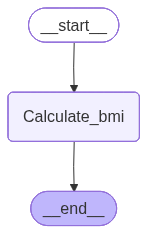

In [16]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())